In [5]:
import pandas as pd
df = pd.read_csv('telco_churn_synthetic.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,C00000,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Credit card (automatic),22.05,23.01,No
1,C00001,Male,1,No,No,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),23.01,,Yes
2,C00002,Female,0,No,No,61,Yes,No,Fiber optic,Yes,...,No,Yes,No,No,Two year,Yes,Electronic check,74.22,4746.13,No
3,C00003,Female,0,Yes,No,9,No,No phone service,DSL,No,...,No,No,No,Yes,One year,Yes,Credit card (automatic),26.40,247.82,No
4,C00004,Male,1,Yes,No,61,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Two year,Yes,Electronic check,85.44,4635.11,No


### EDA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

df = pd.read_csv('telco_churn_synthetic.csv')

print(f"Размер: {df.shape}")
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Дубликаты: {df.duplicated().sum()}")
print(f"Дубликаты по customerID: {df['customerID'].duplicated().sum()}")
# Типы данных и пропуски в одной таблице
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2),
    'sample_values': [df[col].dropna().unique()[:3] for col in df.columns]
})
info_df

Размер: (7000, 21)
Память: 7.71 MB
Дубликаты: 0
Дубликаты по customerID: 0


,dtype,n_unique,n_missing,pct_missing,sample_values
customerID,object,7000,0,0.00,"[C00000, C00001, C00002]"
gender,object,2,0,0.00,"[Female, Male]"
SeniorCitizen,int64,2,0,0.00,"[0, 1]"
Partner,object,2,0,0.00,"[No, Yes]"
Dependents,object,2,0,0.00,"[No, Yes]"
tenure,int64,73,0,0.00,"[1, 0, 61]"
PhoneService,object,2,0,0.00,"[Yes, No]"
MultipleLines,object,3,126,1.80,"[No, Yes, No phone service]"
InternetService,object,3,0,0.00,"[No, Fiber optic, DSL]"
OnlineSecurity,object,3,130,1.86,"[No internet service, Yes, No]"


In [9]:
# Разбираемся с TotalCharges
print("Уникальные не-числовые значения в TotalCharges:")
mask_non_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()
print(df.loc[mask_non_numeric, 'TotalCharges'].value_counts())
print(f"\nВсего проблемных: {mask_non_numeric.sum()}")
print(f"\nИх tenure:")
print(df.loc[mask_non_numeric, 'tenure'].value_counts())
# Преобразуем TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['TotalCharges'].describe()

Уникальные не-числовые значения в TotalCharges:
TotalCharges
    398
Name: count, dtype: int64

Всего проблемных: 398

Их tenure:
tenure
0    398
Name: count, dtype: int64


count    7000.000000
mean     1588.708720
std      1674.322804
min         0.000000
25%       237.567500
50%       890.780000
75%      2725.967500
max      7819.010000
Name: TotalCharges, dtype: float64

Churn
No     0.659
Yes    0.341
Name: proportion, dtype: float64


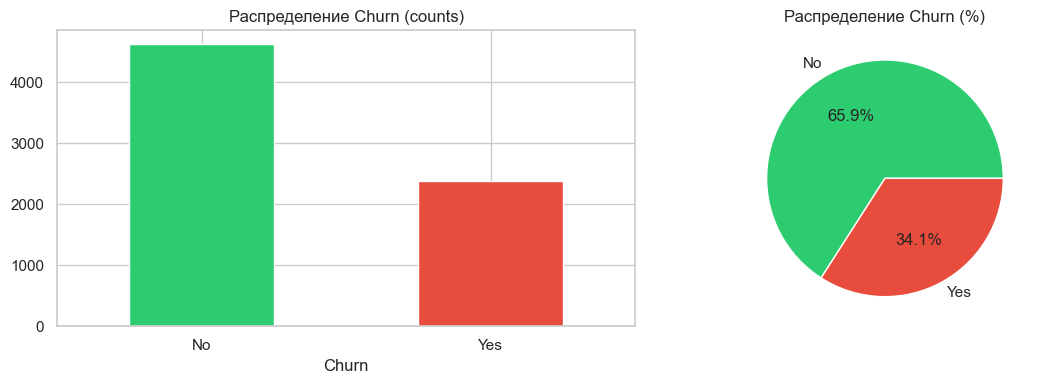

In [10]:
# Кодируем таргет в 0/1 для удобства
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Распределение
target_dist = df['Churn'].value_counts(normalize=True).round(3)
print(target_dist)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Распределение Churn (counts)')
ax[0].set_xticklabels(['No', 'Yes'], rotation=0)

df['Churn'].value_counts(normalize=True).plot(kind='pie', ax=ax[1],
                                                colors=['#2ecc71', '#e74c3c'],
                                                autopct='%1.1f%%')
ax[1].set_title('Распределение Churn (%)')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [11]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Описательная статистика
df[numeric_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7000.00,7000.00,7000.00
mean,27.12,61.73,1588.71
std,24.39,24.75,1674.32
min,0.00,18.00,0.00
25%,5.00,44.50,237.57
50%,17.00,67.34,890.78
75%,50.00,81.31,2725.97
max,72.00,111.77,7819.01


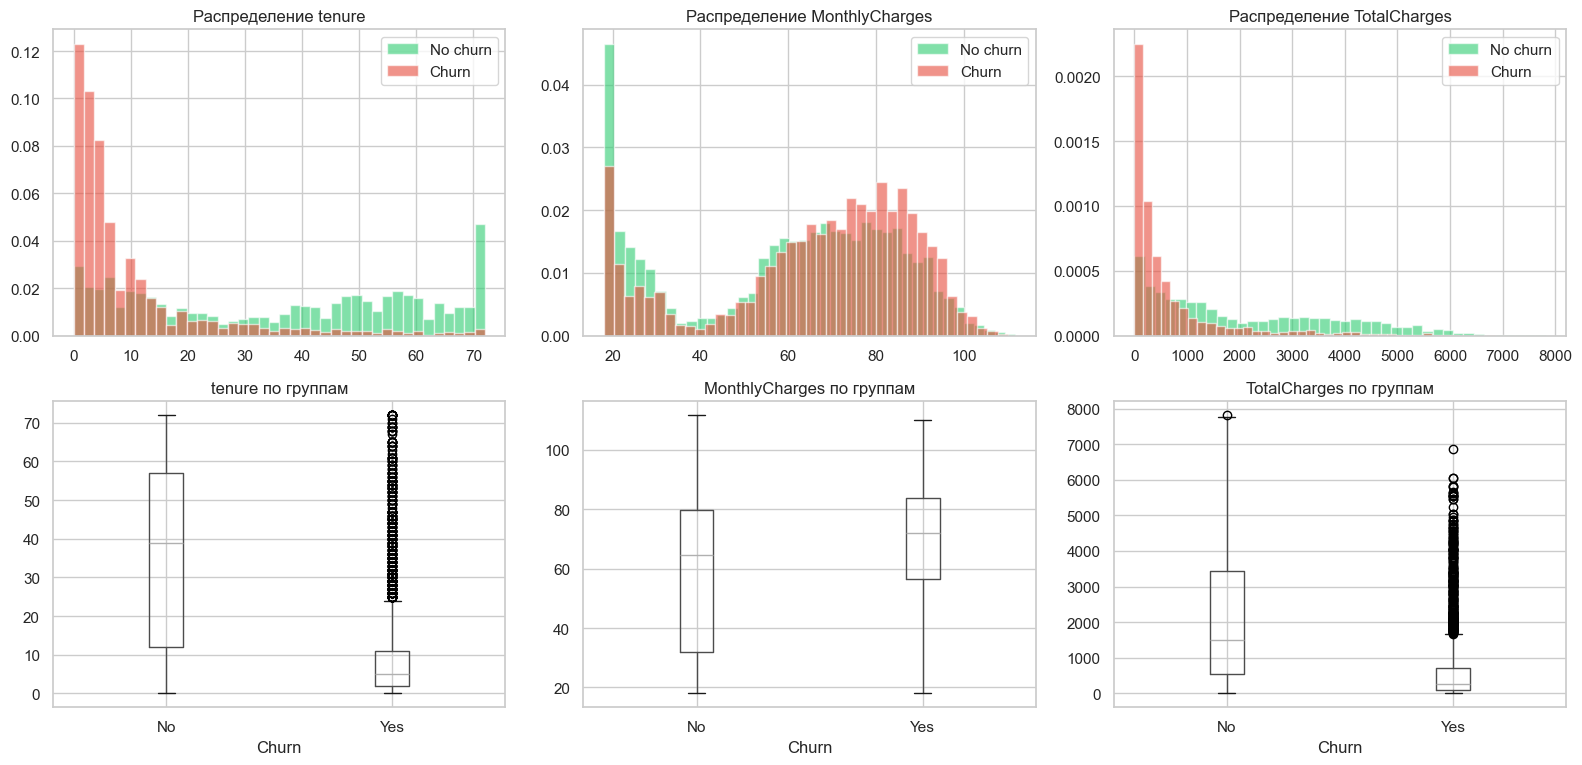

In [12]:
# Распределения числовых фич с разбивкой по таргету
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(numeric_cols):
    # Распределение
    axes[0, i].hist(df[df['Churn'] == 'No'][col], bins=40, alpha=0.6,
                    label='No churn', color='#2ecc71', density=True)
    axes[0, i].hist(df[df['Churn'] == 'Yes'][col], bins=40, alpha=0.6,
                    label='Churn', color='#e74c3c', density=True)
    axes[0, i].set_title(f'Распределение {col}')
    axes[0, i].legend()

    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1, i])
    axes[1, i].set_title(f'{col} по группам')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [13]:
df.groupby('InternetService').apply(
    lambda x: x[['MonthlyCharges', 'Churn_bin']].corr().iloc[0, 1]
).round(3)

/var/folders/6r/hytlw2sn1fs_9jzjy_lsxtg80000gn/T/ipykernel_37211/541102886.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('InternetService').apply(


InternetService
DSL            0.019
Fiber optic    0.002
No             0.045
dtype: float64

In [14]:
df['charges_bucket'] = pd.qcut(df['MonthlyCharges'], q=4,
                                labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

pivot = df.pivot_table(
    index='charges_bucket',
    columns='InternetService',
    values='Churn_bin',
    aggfunc='mean',
    observed=True
).round(3)

print(pivot)

InternetService    DSL  Fiber optic    No
charges_bucket                           
Low              0.259        0.333  0.24
Mid-Low          0.308        0.403   NaN
Mid-High         0.303        0.423   NaN
High             0.265        0.425   NaN


In [15]:
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[-1, 6, 24, 72],
                              labels=['New', 'Mid', 'Loyal'])

df.groupby(['tenure_bucket', 'charges_bucket'], observed=True)['Churn_bin'].agg(
    ['mean', 'count']
).round(3)

mean  count
tenure_bucket charges_bucket              
New           Low             0.551    515
              Mid-Low         0.670    552
              Mid-High        0.730    515
              High            0.750    548
Mid           Low             0.242    451
              Mid-Low         0.333    438
              Mid-High        0.430    454
              High            0.500    436
Loyal         Low             0.040    784
              Mid-Low         0.068    760
              Mid-High        0.114    782
              High            0.136    765

In [17]:
categorical_cols = [c for c in df.columns
                    if df[c].dtype == 'object'
                    and c not in ['customerID', 'Churn']]

print(f"Категориальных фич: {len(categorical_cols)}")

# Cardinality
for c in categorical_cols:
    print(f"{c}: {df[c].nunique()} уникальных значений")

Категориальных фич: 15
gender: 2 уникальных значений
Partner: 2 уникальных значений
Dependents: 2 уникальных значений
PhoneService: 2 уникальных значений
MultipleLines: 3 уникальных значений
InternetService: 3 уникальных значений
OnlineSecurity: 3 уникальных значений
OnlineBackup: 3 уникальных значений
DeviceProtection: 3 уникальных значений
TechSupport: 3 уникальных значений
StreamingTV: 3 уникальных значений
StreamingMovies: 3 уникальных значений
Contract: 3 уникальных значений
PaperlessBilling: 2 уникальных значений
PaymentMethod: 4 уникальных значений


In [18]:
# Churn rate по каждой категории
def churn_rate_by_cat(df, col):
    grouped = df.groupby(col, dropna=False).agg(
        n=('Churn_bin', 'size'),
        churn_rate=('Churn_bin', 'mean')
    ).sort_values('churn_rate', ascending=False)
    grouped['churn_rate'] = (grouped['churn_rate'] * 100).round(1)
    grouped['pct_of_total'] = (grouped['n'] / len(df) * 100).round(1)
    return grouped

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(churn_rate_by_cat(df, col))


=== gender ===
           n  churn_rate  pct_of_total
gender                                
Male    3590        34.7          51.3
Female  3410        33.4          48.7

=== Partner ===
            n  churn_rate  pct_of_total
Partner                                
No       3607        34.9          51.5
Yes      3393        33.2          48.5

=== Dependents ===
               n  churn_rate  pct_of_total
Dependents                                
No          4964        34.7          70.9
Yes         2036        32.6          29.1

=== PhoneService ===
                 n  churn_rate  pct_of_total
PhoneService                                
Yes           6304        34.5          90.1
No             696        30.3           9.9

=== MultipleLines ===
                     n  churn_rate  pct_of_total
MultipleLines                                   
NaN                126        36.5           1.8
Yes               2602        35.3          37.2
No                3585        33.8    

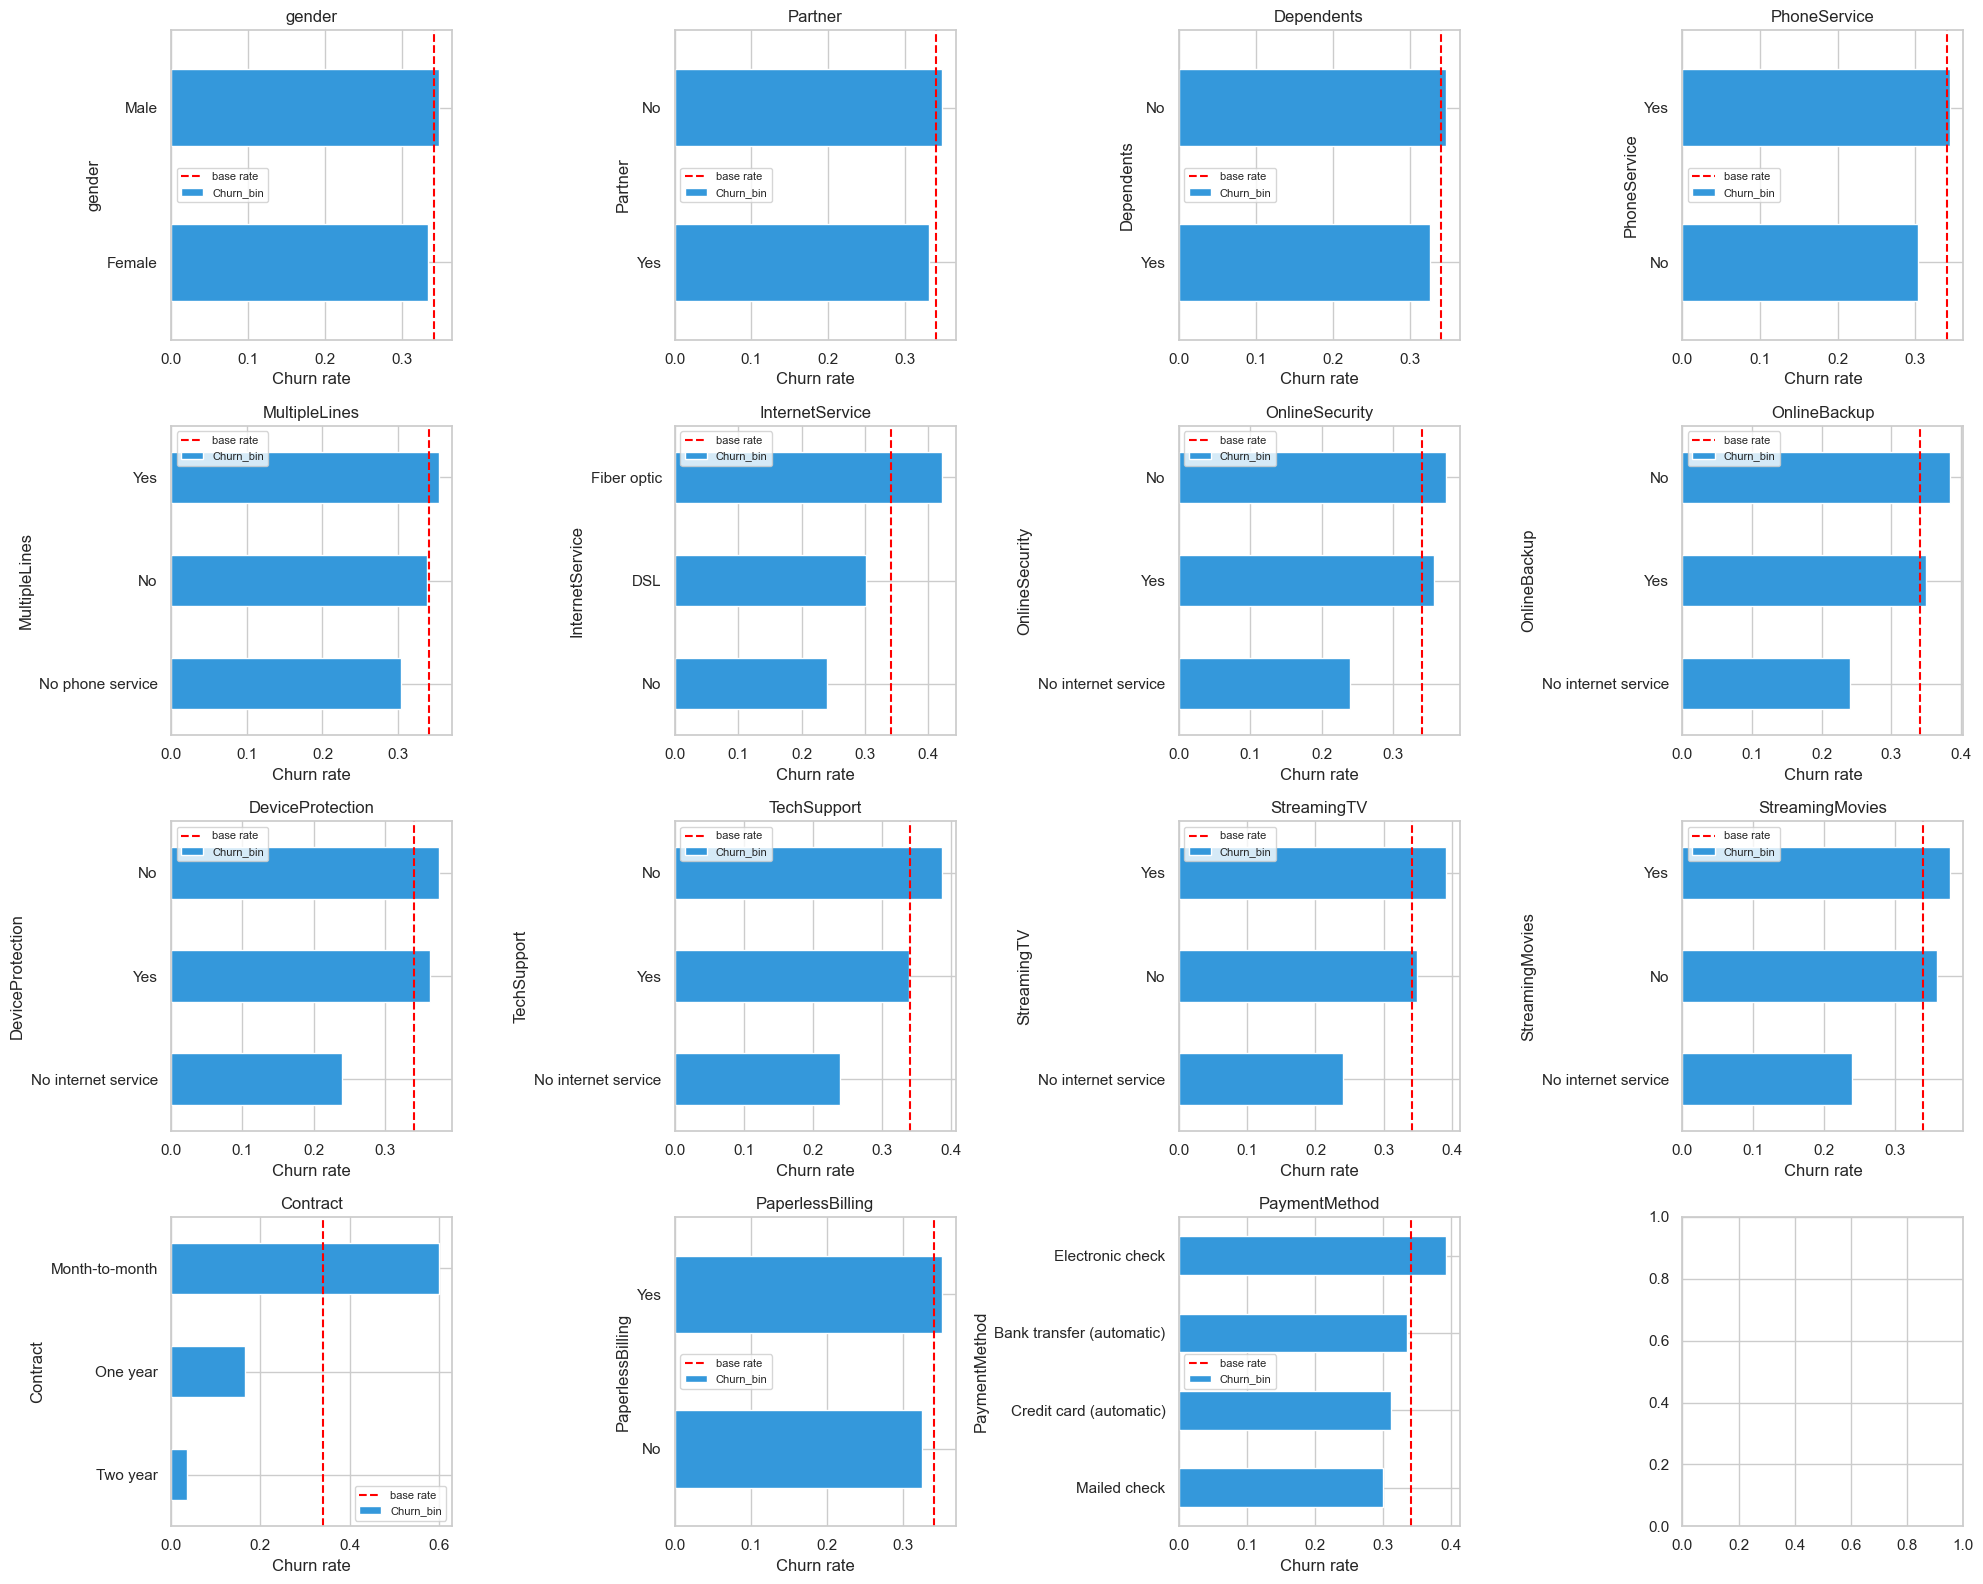

In [19]:
# Визуализация: топ-фичи по силе связи с churn
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:16]):
    cr = df.groupby(col)['Churn_bin'].mean().sort_values()
    cr.plot(kind='barh', ax=axes[i], color='#3498db')
    axes[i].axvline(x=df['Churn_bin'].mean(), color='red',
                    linestyle='--', label='base rate')
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn rate')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

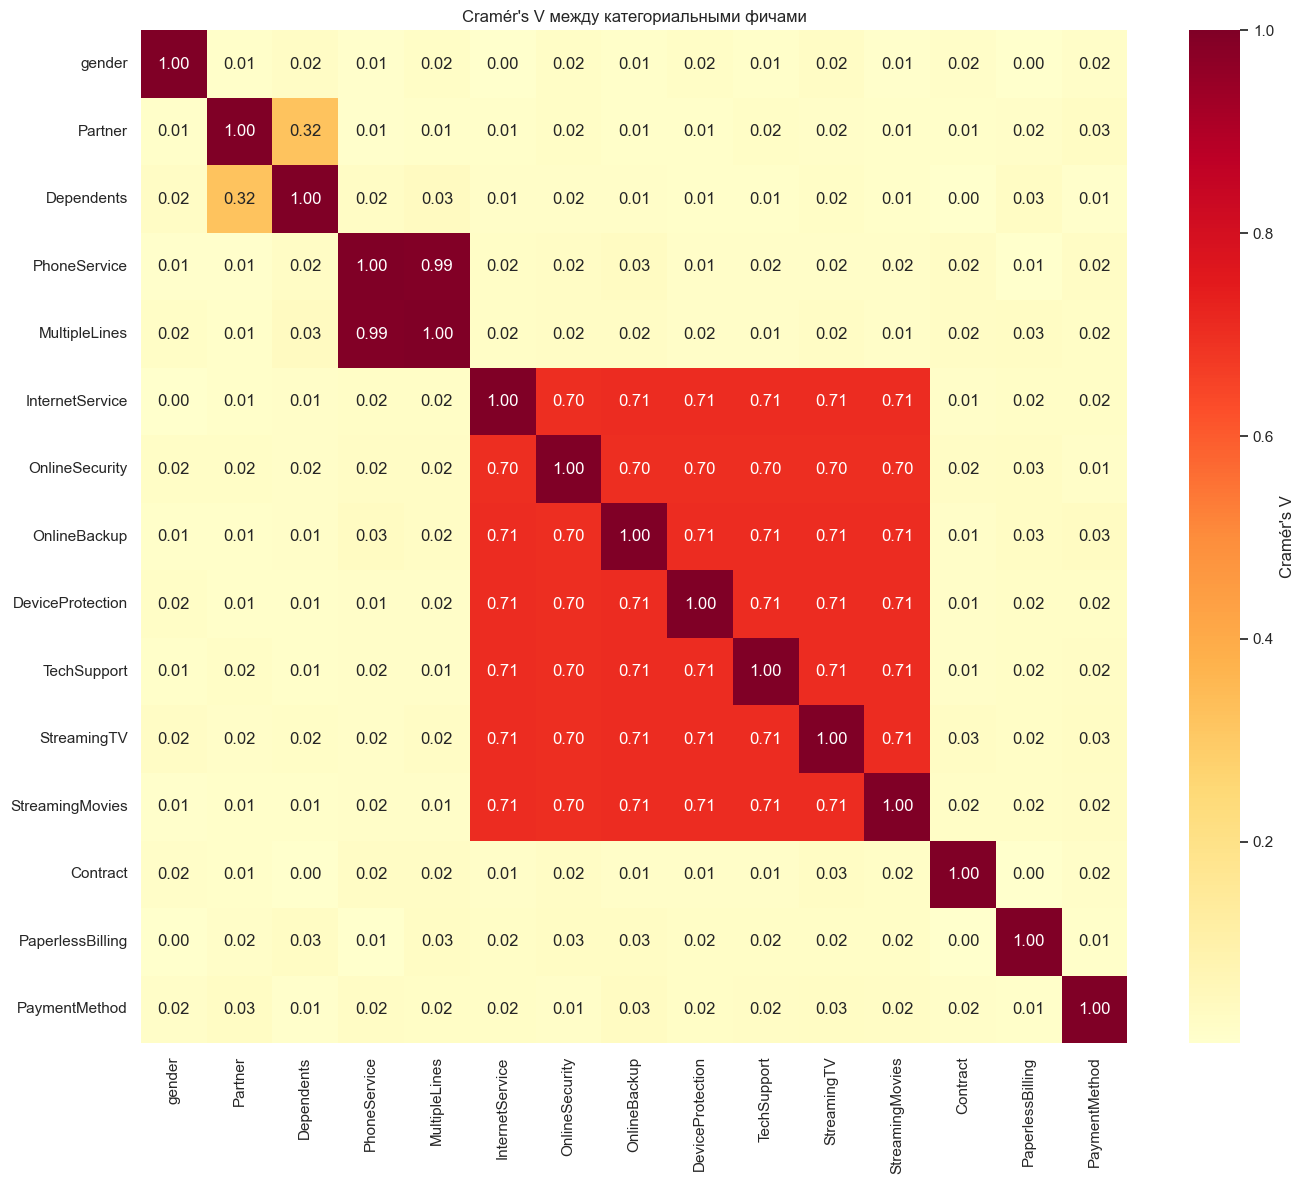

In [20]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Матрица Cramér's V
cat_for_corr = [c for c in categorical_cols if df[c].nunique() < 10]
cv_matrix = pd.DataFrame(index=cat_for_corr, columns=cat_for_corr, dtype=float)

for c1 in cat_for_corr:
    for c2 in cat_for_corr:
        cv_matrix.loc[c1, c2] = cramers_v(df[c1].fillna('NA'), df[c2].fillna('NA'))

plt.figure(figsize=(14, 12))
sns.heatmap(cv_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': "Cramér's V"})
plt.title("Cramér's V между категориальными фичами")
plt.tight_layout()
plt.show()

### Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('telco_churn_synthetic.csv')

# === 1. Чиним TotalCharges ===
# Помним: пробелы для tenure=0. Это не пропуск, это структурный 0.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# === 2. Таргет в 0/1 ===
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# === 3. Пропуски в категориальных ===
# Стратегия: NaN -> отдельная категория 'Unknown' + флаг
# Почему так, а не impute модой: на EDA мы видели, что пропуск может быть информативен
for col in ['MultipleLines', 'OnlineSecurity']:
    df[f'{col}_was_missing'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna('Unknown')

# === 4. Удаляем ID — он не фича ===
df_clean = df.drop(columns=['customerID'])

print(f"Размер после чистки: {df_clean.shape}")
print(f"Пропусков осталось: {df_clean.isnull().sum().sum()}")
print(f"Распределение таргета: {df_clean['Churn'].mean():.3f}")

Размер после чистки: (7000, 22)
Пропусков осталось: 0
Распределение таргета: 0.341


In [22]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # сохраняем долю классов
    random_state=42
)

print(f"Train: {X_train.shape}, churn rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, churn rate: {y_test.mean():.3f}")

Train: (5600, 21), churn rate: 0.341
Test:  (1400, 21), churn rate: 0.341


In [24]:
def add_temporal_features(df):
    df = df.copy()
    
    # A1. Средний платёж за всю историю
    # Гипотеза: отличается от MonthlyCharges если клиент менял тариф.
    # Если AvgChargesPerMonth < MonthlyCharges => недавно повысил тариф => риск.
    df['AvgChargesPerMonth'] = np.where(
        df['tenure'] > 0,
        df['TotalCharges'] / df['tenure'],
        df['MonthlyCharges']  # для новичков — текущий чек
    )
    
    # A2. Дельта между текущим и средним чеком
    # Гипотеза: положительная дельта = повышение тарифа = риск разочарования
    df['ChargesDelta'] = df['MonthlyCharges'] - df['AvgChargesPerMonth']
    
    # A3. Бакеты tenure
    # Гипотеза: для линейных моделей нелинейность tenure важна.
    # Бустинги сами найдут, но для интерпретации полезно.
    df['tenure_bucket'] = pd.cut(
        df['tenure'],
        bins=[-1, 6, 12, 24, 48, 72],
        labels=['0-6', '7-12', '13-24', '25-48', '49-72']
    )
    
    # A4. Флаг новичка
    # Гипотеза: первые 6 месяцев — самый рискованный период.
    df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
    
    return df

X_train = add_temporal_features(X_train)
X_test = add_temporal_features(X_test)
def add_services_features(df):
    df = df.copy()
    
    # B1. Количество защитных услуг
    # Гипотеза: чем больше защитных услуг, тем глубже отношения с компанией.
    protective_services = ['OnlineSecurity', 'OnlineBackup',
                            'DeviceProtection', 'TechSupport']
    df['ProtectiveServicesCount'] = sum(
        (df[s] == 'Yes').astype(int) for s in protective_services
    )
    
    # B2. Количество стриминг-услуг
    # Гипотеза: стриминг — глобальный сервис, не привязывает к провайдеру.
    streaming_services = ['StreamingTV', 'StreamingMovies']
    df['StreamingServicesCount'] = sum(
        (df[s] == 'Yes').astype(int) for s in streaming_services
    )
    
    # B3. Общее число услуг
    # Гипотеза: общая глубина продуктового использования.
    all_services = protective_services + streaming_services + ['PhoneService', 'MultipleLines']
    df['TotalServicesCount'] = sum(
        df[s].isin(['Yes']).astype(int) for s in all_services
    )
    
    # B4. Флаг «голый» клиент (только базовая услуга)
    # Гипотеза: клиенты без доп. услуг — наименее привязанные.
    df['has_no_addons'] = (df['ProtectiveServicesCount'] == 0).astype(int)
    
    return df

X_train = add_services_features(X_train)
X_test = add_services_features(X_test)
def add_financial_features(df):
    df = df.copy()
    
    # C1. Цена за услугу
    # Гипотеза: высокий чек на мало услуг = клиент чувствует, что переплачивает.
    df['ChargesPerService'] = df['MonthlyCharges'] / (df['TotalServicesCount'] + 1)
    
    # C2. Лог-преобразование TotalCharges
    # Гипотеза: распределение сильно скошено, лог сделает его нормальнее (для линейных моделей).
    df['TotalCharges_log'] = np.log1p(df['TotalCharges'])
    
    # C3. Бакеты MonthlyCharges
    # Гипотеза: эффект цены нелинейный — есть пороги «дешёвый/средний/дорогой».
    df['charges_bucket'] = pd.cut(
        df['MonthlyCharges'],
        bins=[0, 35, 65, 90, 200],
        labels=['Low', 'Mid', 'High', 'Premium']
    )
    
    return df

X_train = add_financial_features(X_train)
X_test = add_financial_features(X_test)
def add_interaction_features(df):
    df = df.copy()
    
    # D1. Высокорисковая комбинация: месячный контракт + оптоволокно
    # Гипотеза: обе фичи сильные, их пересечение должно усиливать сигнал.
    df['risky_combo'] = (
        (df['Contract'] == 'Month-to-month') &
        (df['InternetService'] == 'Fiber optic')
    ).astype(int)
    
    # D2. «Идеальный лояльный» клиент
    # Гипотеза: длинный контракт + автоплатёж = почти не уходит.
    df['loyal_combo'] = (
        (df['Contract'].isin(['One year', 'Two year'])) &
        (df['PaymentMethod'].isin(['Bank transfer (automatic)',
                                    'Credit card (automatic)']))
    ).astype(int)
    
    # D3. Семейный профиль
    # Гипотеза: семья + длинный контракт = очень стабильный сегмент.
    df['family_stable'] = (
        (df['Partner'] == 'Yes') &
        (df['Dependents'] == 'Yes') &
        (df['Contract'] != 'Month-to-month')
    ).astype(int)
    
    return df

X_train = add_interaction_features(X_train)
X_test = add_interaction_features(X_test)
# Пример: target encoding для PaymentMethod
# ПРИНЦИП: статистики считаем ТОЛЬКО на train, применяем к обоим
target_means = X_train.assign(Churn=y_train).groupby('PaymentMethod')['Churn'].mean()

# Для регуляризации: смешиваем с глобальным средним (smoothing)
global_mean = y_train.mean()
counts = X_train['PaymentMethod'].value_counts()
smoothing = 10  # чем больше, тем сильнее регуляризация
target_encoded = (target_means * counts + global_mean * smoothing) / (counts + smoothing)

X_train['PaymentMethod_te'] = X_train['PaymentMethod'].map(target_encoded)
X_test['PaymentMethod_te'] = X_test['PaymentMethod'].map(target_encoded)
# Если в тесте появится незнакомая категория — заполнить глобальным средним
X_test['PaymentMethod_te'] = X_test['PaymentMethod_te'].fillna(global_mean)

In [25]:
# Список финальных категориальных фич
categorical_final = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'tenure_bucket', 'charges_bucket'
]

# === Версия для бустинга: категории как category dtype ===
X_train_gbm = X_train.copy()
X_test_gbm = X_test.copy()

for col in categorical_final:
    X_train_gbm[col] = X_train_gbm[col].astype('category')
    # Важно: используем те же категории, что в train
    X_test_gbm[col] = pd.Categorical(
        X_test_gbm[col],
        categories=X_train_gbm[col].cat.categories
    )

# === Версия для линейной модели: one-hot ===
X_train_linear = pd.get_dummies(X_train, columns=categorical_final, drop_first=True)
X_test_linear = pd.get_dummies(X_test, columns=categorical_final, drop_first=True)

# Выравниваем колонки (вдруг в train есть категория, которой нет в test, или наоборот)
X_test_linear = X_test_linear.reindex(columns=X_train_linear.columns, fill_value=0)

print(f"Размер для бустинга: {X_train_gbm.shape}")
print(f"Размер для линейной: {X_train_linear.shape}")

Размер для бустинга: (5600, 36)
Размер для линейной: (5600, 54)


In [26]:
def sanity_check(X_train, X_test, y_train, y_test, name=''):
    print(f"=== Sanity check: {name} ===")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print(f"Train churn rate: {y_train.mean():.3f}")
    print(f"Test churn rate: {y_test.mean():.3f}")
    
    # Проверка 1: нет ли NaN
    train_nans = X_train.isnull().sum().sum()
    test_nans = X_test.isnull().sum().sum()
    print(f"NaN в train: {train_nans}, в test: {test_nans}")
    
    # Проверка 2: те же колонки в train и test
    assert list(X_train.columns) == list(X_test.columns), "Колонки не совпадают!"
    print("Колонки совпадают: OK")
    
    # Проверка 3: типы данных
    diff_types = []
    for col in X_train.columns:
        if str(X_train[col].dtype) != str(X_test[col].dtype):
            diff_types.append(col)
    print(f"Колонок с разными типами: {len(diff_types)}")
    if diff_types:
        print(f"  {diff_types[:5]}")
    
    # Проверка 4: бесконечности (могут вылезти из деления)
    if X_train.select_dtypes(include=[np.number]).shape[1] > 0:
        train_inf = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
        test_inf = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
        print(f"Inf в train: {train_inf}, в test: {test_inf}")
    
    print()

sanity_check(X_train_gbm, X_test_gbm, y_train, y_test, name='GBM')
sanity_check(X_train_linear, X_test_linear, y_train, y_test, name='Linear')

=== Sanity check: GBM ===
Train shape: (5600, 36), Test shape: (1400, 36)
Train churn rate: 0.341
Test churn rate: 0.341
NaN в train: 0, в test: 0
Колонки совпадают: OK
Колонок с разными типами: 0
Inf в train: 0, в test: 0

=== Sanity check: Linear ===
Train shape: (5600, 54), Test shape: (1400, 54)
Train churn rate: 0.341
Test churn rate: 0.341
NaN в train: 0, в test: 0
Колонки совпадают: OK
Колонок с разными типами: 0
Inf в train: 0, в test: 0



### Обучение моделей

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, log_loss
)

# Основные метрики и почему они нам нужны:
SCORING = {
    'roc_auc': 'roc_auc',                    # общая разделяющая способность
    'pr_auc': 'average_precision',           # ВАЖНЕЕ для дисбаланса классов
    'f1': 'f1',                              # баланс precision/recall
    'precision': 'precision',                # доля истинных среди предсказанных positives
    'recall': 'recall',                      # доля пойманных positives
    'neg_log_loss': 'neg_log_loss',          # калибровка вероятностей
}
# Стратифицированная 5-fold кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [29]:
def evaluate_model(model, X, y, cv, model_name='Model'):
    """Прогоняет CV и возвращает агрегированные метрики."""
    results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1
    )
    
    summary = {}
    for metric in SCORING.keys():
        test_scores = results[f'test_{metric}']
        train_scores = results[f'train_{metric}']
        summary[f'{metric}_test_mean'] = test_scores.mean()
        summary[f'{metric}_test_std'] = test_scores.std()
        summary[f'{metric}_train_mean'] = train_scores.mean()
        # Гэп train-test: индикатор переобучения
        summary[f'{metric}_gap'] = train_scores.mean() - test_scores.mean()
    
    summary['model'] = model_name
    return summary

In [31]:
from sklearn.dummy import DummyClassifier

# "Stratified" — предсказывает классы пропорционально их частоте в train
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy_results = evaluate_model(dummy, X_train_gbm.drop(columns=['tenure_bucket', 'charges_bucket']),
                                y_train, cv, 'Dummy (stratified)')

# Чуть умнее: предсказывает всегда мажоритарный класс
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_maj_results = evaluate_model(dummy_majority,
                                    X_train_gbm.drop(columns=['tenure_bucket', 'charges_bucket']),
                                    y_train, cv, 'Dummy (majority)')

print(f"Dummy stratified PR-AUC: {dummy_results['pr_auc_test_mean']:.3f}")
print(f"Dummy majority PR-AUC: {dummy_maj_results['pr_auc_test_mean']:.3f}")
print(f"Dummy stratified ROC-AUC: {dummy_results['roc_auc_test_mean']:.3f}")

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_clas

Dummy stratified PR-AUC: 0.340
Dummy majority PR-AUC: 0.341
Dummy stratified ROC-AUC: 0.499


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline объединяет масштабирование и модель в один объект
# Это важно для CV: scaler фитится только на train fold, а не на всём X
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',  # компенсация дисбаланса
        random_state=42
    ))
])

logreg_results = evaluate_model(logreg_pipeline, X_train_linear, y_train, cv, 'LogReg')

print(f"LogReg PR-AUC: {logreg_results['pr_auc_test_mean']:.3f} ± {logreg_results['pr_auc_test_std']:.3f}")
print(f"LogReg ROC-AUC: {logreg_results['roc_auc_test_mean']:.3f}")
print(f"LogReg gap (train-test) PR-AUC: {logreg_results['pr_auc_gap']:.3f}")

LogReg PR-AUC: 0.806 ± 0.018
LogReg ROC-AUC: 0.897
LogReg gap (train-test) PR-AUC: 0.008


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,    # регуляризация
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# RF не нуждается в one-hot, но и категории как 'category' напрямую не ест
# Используем линейную версию (там one-hot уже готов)
rf_results = evaluate_model(rf, X_train_linear, y_train, cv, 'RandomForest')

print(f"RF PR-AUC: {rf_results['pr_auc_test_mean']:.3f} ± {rf_results['pr_auc_test_std']:.3f}")
print(f"RF gap: {rf_results['pr_auc_gap']:.3f}")

RF PR-AUC: 0.798 ± 0.023
RF gap: 0.052


In [36]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# LightGBM нативно работает с category dtype — используем X_train_gbm
lgbm_results = evaluate_model(lgbm, X_train_gbm, y_train, cv, 'LightGBM (default)')

print(f"LightGBM PR-AUC: {lgbm_results['pr_auc_test_mean']:.3f} ± {lgbm_results['pr_auc_test_std']:.3f}")
print(f"LightGBM gap: {lgbm_results['pr_auc_gap']:.3f}")

LightGBM PR-AUC: 0.784 ± 0.015
LightGBM gap: 0.207


In [37]:
all_results = pd.DataFrame([
    dummy_results, dummy_maj_results,
    logreg_results, rf_results, lgbm_results
])

# Выводим основные метрики красиво
display_cols = ['model', 'pr_auc_test_mean', 'pr_auc_test_std',
                'roc_auc_test_mean', 'f1_test_mean',
                'precision_test_mean', 'recall_test_mean',
                'pr_auc_gap']

comparison = all_results[display_cols].round(3)
comparison.columns = ['Model', 'PR-AUC', 'PR-AUC std', 'ROC-AUC',
                       'F1', 'Precision', 'Recall', 'Gap']
print(comparison.to_string(index=False))

             Model  PR-AUC  PR-AUC std  ROC-AUC    F1  Precision  Recall   Gap
Dummy (stratified)   0.340       0.002    0.499 0.335      0.340   0.330 0.000
  Dummy (majority)   0.341       0.000    0.500 0.000      0.000   0.000 0.000
            LogReg   0.806       0.018    0.897 0.752      0.677   0.847 0.008
      RandomForest   0.798       0.023    0.890 0.744      0.682   0.821 0.052
LightGBM (default)   0.784       0.015    0.884 0.734      0.694   0.780 0.207


In [38]:
# Обучим на полном train, чтобы извлечь коэффициенты
logreg_pipeline.fit(X_train_linear, y_train)

coef_df = pd.DataFrame({
    'feature': X_train_linear.columns,
    'coef': logreg_pipeline.named_steps['clf'].coef_[0]
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(20)

print("Топ-20 фич по абсолютному коэффициенту логрега:")
print(coef_df[['feature', 'coef']].to_string(index=False))

Топ-20 фич по абсолютному коэффициенту логрега:
                           feature      coef
                 Contract_Two year -1.240183
                            tenure -1.200230
                 Contract_One year -0.825465
       InternetService_Fiber optic  0.377655
                   is_new_customer  0.233001
OnlineSecurity_No internet service  0.201371
                     SeniorCitizen  0.173864
                  PhoneService_Yes  0.153064
                   TechSupport_Yes -0.150210
                 ChargesPerService  0.146346
                      TotalCharges  0.142269
                tenure_bucket_7-12 -0.132506
                       Partner_Yes -0.132353
                  PaymentMethod_te  0.116018
           ProtectiveServicesCount -0.112669
                     family_stable -0.103759
    PaymentMethod_Electronic check  0.103597
    MultipleLines_No phone service  0.095515
              PaperlessBilling_Yes  0.094003
               tenure_bucket_13-24 -0.089700


In [39]:
lgbm.fit(X_train_gbm, y_train)

fi_df = pd.DataFrame({
    'feature': X_train_gbm.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False).head(20)

print("\nТоп-20 фич по importance в LightGBM:")
print(fi_df.to_string(index=False))


Топ-20 фич по importance в LightGBM:
                feature  importance
           ChargesDelta        1222
      ChargesPerService        1184
     AvgChargesPerMonth         993
           TotalCharges         990
         MonthlyCharges         966
                 tenure         859
       PaymentMethod_te         389
               Contract         300
                Partner         225
                 gender         189
ProtectiveServicesCount         162
            TechSupport         156
       PaperlessBilling         144
          SeniorCitizen         132
 StreamingServicesCount         124
           OnlineBackup         123
             Dependents         120
        StreamingMovies         106
        InternetService          98
       DeviceProtection          93


In [40]:
# Стандартное правило: scale_pos_weight = neg/pos ratio
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Соотношение neg/pos: {ratio:.2f}")  # ~1.94

Соотношение neg/pos: 1.94


In [41]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# A. Без работы с дисбалансом
lgbm_plain = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=42, n_jobs=-1, verbose=-1
)
score_plain = cross_val_score(lgbm_plain, X_train_gbm, y_train,
                               cv=cv, scoring='average_precision', n_jobs=-1)

# B. scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
lgbm_weighted = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=ratio,
    random_state=42, n_jobs=-1, verbose=-1
)
score_weighted = cross_val_score(lgbm_weighted, X_train_gbm, y_train,
                                  cv=cv, scoring='average_precision', n_jobs=-1)

# C. class_weight='balanced' (то же, что мы делали в baseline)
lgbm_balanced = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
score_balanced = cross_val_score(lgbm_balanced, X_train_gbm, y_train,
                                  cv=cv, scoring='average_precision', n_jobs=-1)

print(f"Без дисбаланса:        PR-AUC = {score_plain.mean():.4f} ± {score_plain.std():.4f}")
print(f"scale_pos_weight:      PR-AUC = {score_weighted.mean():.4f} ± {score_weighted.std():.4f}")
print(f"class_weight=balanced: PR-AUC = {score_balanced.mean():.4f} ± {score_balanced.std():.4f}")

Без дисбаланса:        PR-AUC = 0.7818 ± 0.0220
scale_pos_weight:      PR-AUC = 0.7852 ± 0.0134
class_weight=balanced: PR-AUC = 0.7843 ± 0.0153


In [44]:
import optuna
from sklearn.model_selection import KFold
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import average_precision_score
import numpy as np

# Чтобы Optuna не засорял output
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # === Search space ===
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'verbosity': -1,
        'n_estimators': 1000,  # большой запас, early stopping остановит
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 8, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
    }
    
    # === Cross-validation внутри objective ===
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_gbm, y_train)):
        X_fold_train = X_train_gbm.iloc[train_idx]
        X_fold_val = X_train_gbm.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        model = LGBMClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train,
            eval_set=[(X_fold_val, y_fold_val)],
            eval_metric='average_precision',
            callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        # Предсказание с лучшим числом итераций
        y_pred = model.predict_proba(X_fold_val)[:, 1]
        score = average_precision_score(y_fold_val, y_pred)
        scores.append(score)
    
    return np.mean(scores)


# === Запускаем оптимизацию ===
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),  # фиксируем seed для воспроизводимости
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=20)  # отсекает плохие trials
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n=== Результаты тюнинга ===")
print(f"Лучший PR-AUC: {study.best_value:.4f}")
print(f"\nЛучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

ModuleNotFoundError: No module named 'optuna'